## Download the dataset from the kaggle and Unzip it.

In [59]:
!kaggle datasets download -d rakeshrau/social-network-ads --unzip

Dataset URL: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
License(s): unknown
100%|██████████████████████████████████████| 3.27k/3.27k [00:00<00:00, 5.35kB/s]



## Convert the dataset in  Pandas DataFrame

In [60]:
import pandas as pd

df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
206,15654230,Female,55,130000,1
139,15741094,Male,19,25000,0
137,15687491,Male,30,107000,1
32,15573452,Female,21,16000,0
337,15612465,Male,35,79000,0


## we want only the three column for now to understand the `StanderdScaler`.

In [61]:
df = df.iloc[:, 2:]
df.sample(5)

,Age,EstimatedSalary,Purchased
230,35,147000,1
176,35,47000,0
295,36,63000,0
79,26,17000,0
62,23,66000,0


In [62]:
df.shape

(400, 3)

## Train Test Split
- test size = 0.3 means, 30% will be a test data and 70% will be only trained for the model building.
- try changing `random state` and see if there is change in `accuracy` of the model.

In [63]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


- `Note:` the mean of Age &  EstimatedSalary has a huge difference.
- This is because the range of age is (18-60) where the range of EstimatedSalary is (15,000 - 1,50,000).
- And if we train the data with any Algorithm which uses Distance between the datapoints to calculate Error, then this huge difference of the range of columns will affact a lot in -ve way.

In [64]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


# StanderdScaler

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# It learned the mean and standard deviation of the features in the training data (x_train) and then applied the transformation to both the training and test data (x_train_scaled and x_test_scaled). This ensures that both datasets are scaled consistently based on the statistics of the training data.
scaler.fit(x_train)


# Results in numpy.ndarray with mean 0 and standard deviation 1
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [66]:
type(x_train_scaled), type(x_test_scaled)

(numpy.ndarray, numpy.ndarray)

- So, we need to change this numpy array into a pandas dataframe.

In [67]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

- We can see the mean of both the columns are nearly 0 and the Std. of both the columns are nearly 1.

In [68]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


- Proof of the above statement.

In [69]:
import numpy as np
print('x_train_scaled mean: ')

print(np.round(x_train_scaled.mean(), 1), '\n')
print('x_train mean: ')
print(np.round(x_train.min(), 1), '\n',)

print('x_train_scaled std: ')
print(np.round(x_train_scaled.std(ddof=0), 1))

x_train_scaled mean: 
Age                0.0
EstimatedSalary    0.0
dtype: float64 

x_train mean: 
Age                   18
EstimatedSalary    15000
dtype: int64 

x_train_scaled std: 
Age                1.0
EstimatedSalary    1.0
dtype: float64


## Effect of Scaling

- This Demonstrate that the shape of the data remains same before and after scaling.

Text(0.5, 1.0, 'After Scaling')

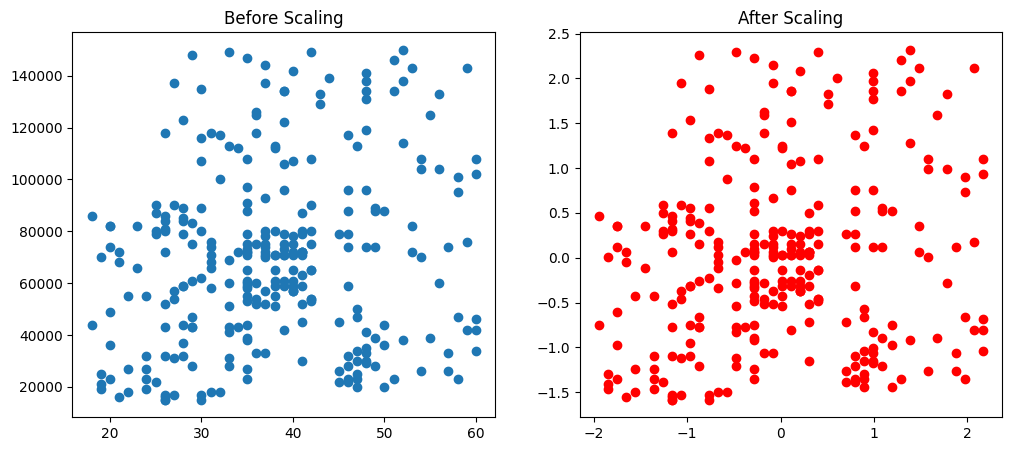

In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_train['Age'], x_train['EstimatedSalary'])
axes[0].set_title('Before Scaling')
axes[1].scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color='red')
axes[1].set_title('After Scaling')

## KDE Plot
- We observed that when data where not scaled, since the range of the datapoints for both column were very high that is when in the first graph the x-axis is not divided in a suitable range to shouw the destribution of age and EstimatedSalary nicely.
- whereas, After standerdization both has the range of `[-1,1]` and that is whey we can see the plots of both very clearly, and its very easy to do analysis now.

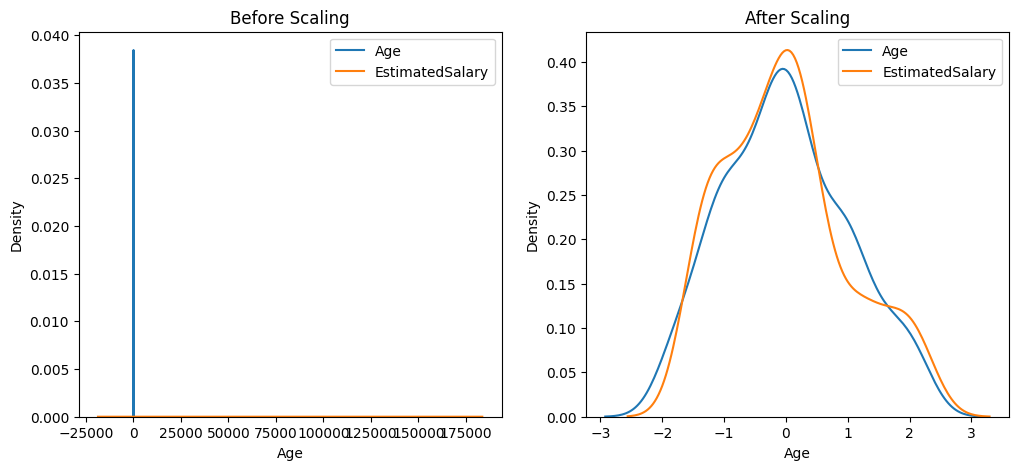

In [71]:
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(
    x=x_train['Age'], ax=axes[0]
)

sns.kdeplot(
    x=x_train['EstimatedSalary'], ax=axes[0]
)

sns.kdeplot(
    x=x_train_scaled['Age'],ax=axes[1]
)
sns.kdeplot(
    x=x_train_scaled['EstimatedSalary'], ax=axes[1]
)

axes[0].legend(['Age', 'EstimatedSalary'])
axes[1].legend(['Age', 'EstimatedSalary'])

axes[0].set_title('Before Scaling')
axes[1].set_title('After Scaling')  

plt.show()

- This Plot again showing that the shape of the data remains same before and after scaling.
- Probability Density Function Plot for Age column.

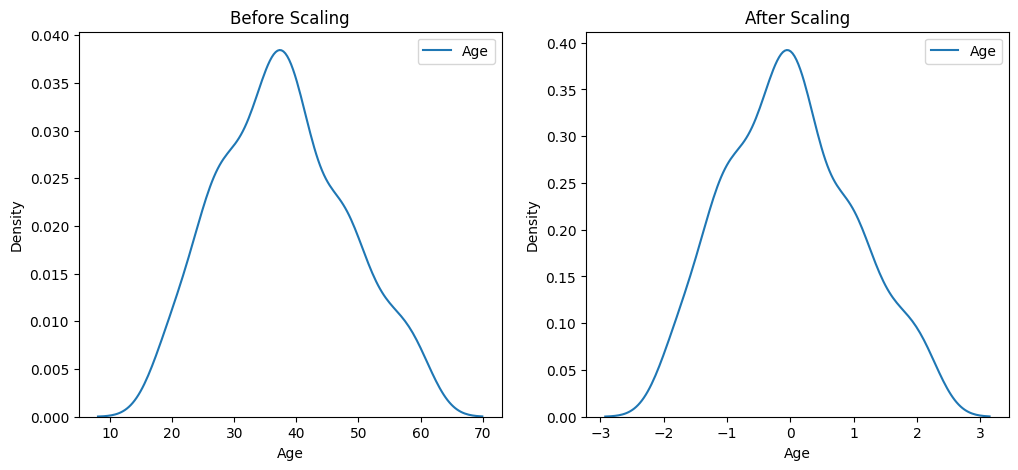

In [72]:
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(
    x=x_train['Age'], ax=axes[0]
)


sns.kdeplot(
    x=x_train_scaled['Age'],ax=axes[1]
)

axes[0].legend(['Age', 'EstimatedSalary'])
axes[1].legend(['Age', 'EstimatedSalary'])

axes[0].set_title('Before Scaling')
axes[1].set_title('After Scaling')  

plt.show()

- This Plot again showing that the shape of the data remains same before and after scaling.
- Probability Density Function Plot for EstimatedSalary column.

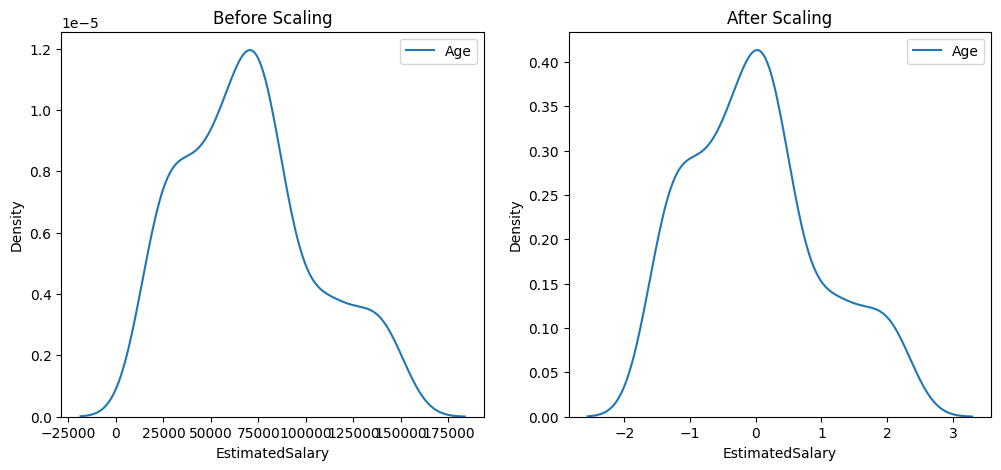

In [73]:
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(12,5))


sns.kdeplot(
    x=x_train['EstimatedSalary'], ax=axes[0]
)


sns.kdeplot(
    x=x_train_scaled['EstimatedSalary'], ax=axes[1]
)

axes[0].legend(['Age', 'EstimatedSalary'])
axes[1].legend(['Age', 'EstimatedSalary'])

axes[0].set_title('Before Scaling')
axes[1].set_title('After Scaling')  

plt.show()

## Why scaling is important ?

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

from sklearn.metrics import accuracy_score

print('Accuracy before scaling: ', accuracy_score(y_test, y_pred))
print('Accuracy after scaling: ', accuracy_score(y_test, y_pred_scaled))

Accuracy before scaling:  0.875
Accuracy after scaling:  0.8666666666666667


In [75]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
print(f"Iterations: {lr.n_iter_}")  # Output: 65 Itrations (converged!)

# With scaling
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(x_train_scaled, y_train)
print(f"Iterations: {lr_scaled.n_iter_}")  # Output: 7 Itrations (converged!)

Iterations: [65]
Iterations: [7]


# Linear Regression & Logistic Regression: Understanding Convergence and Scaling

## Summary of My Results

Accuracy before scaling:  0.875
Accuracy after scaling:   0.8666666666666667

**Conclusion**: Both models achieved nearly identical accuracy (difference of only 0.008), confirming that **scaling is not strictly necessary for this small dataset**, but it's still **best practice** for future use.

---

## What Does "Converge" Mean?

**Convergence** means: The algorithm **stops improving** and finds the **best possible weights** (coefficients) for the model.

### Visual Analogy
Imagine I'm on a mountain and want to reach the lowest point (valley). I take steps downward until I can't go lower anymore. At that point, I've **converged** to the minimum.

### Without Scaling vs With Scaling

| Aspect | Without Scaling | With Scaling |
|--------|-----------------|--------------|
| **Feature Range** | Age: 20-48, Salary: 29,000-71,000 | Both: mean=0, std=1 |
| **Gradient Magnitude** | Age: ~0.5, Salary: ~50,000 | Both: ~0.5 |
| **Weight Updates** | Bounces wildly (overshoots) | Smooth, steady progress |
| **Iterations Needed** | Many (5,000+) | Few (50-150) |
| **Convergence Speed** | Slow | Fast |

---

## The 3 Key Points I Need to Understand

### 1. Similar Accuracy With or Without Scaling (If Model Converges)

**Meaning**: If I let the algorithm run **long enough** to find optimal weights, both versions will give **similar accuracy**.

**Why?**
- The decision boundary is the same regardless of scale
- The model just finds different coefficient values that produce the same predictions
- Once converged, both models make equally good predictions

**In My Case**: Both models achieved ~87% accuracy because both **converged** to optimal weights.

---

### 2. Slower Convergence Without Scaling (May Need More Iterations)

**Meaning**: Without scaling, the algorithm takes **many more steps** to reach the optimal solution.

**Example**:
```python
# Without scaling
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
print(f"Iterations: {lr.n_iter_}")  # Output: Iterations: [65]


# With scaling
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(x_train_scaled, y_train) 
print(f"Iterations: {lr_scaled.n_iter_}")  # Output: Iterations: [7] (converged quickly!)
```

**What Happens**:
- **Without scaling**: Weights "bounce back and forth" like a ball in a valley, taking many iterations
- **With scaling**: Weights move smoothly toward optimal, converging faster

---

### 3. Potential Numerical Issues With Large Salary Values

**Meaning**: Very large numbers (like 63,000) can cause **computer precision problems**.

**The Problem**:
```python
# Sigmoid function: sigma(z) = 1 / (1 + exp(-z))

# With unscaled salary:
z = 1 * 63000  # weight * salary = 63,000
exp(-63000) = extremely tiny --> causes overflow!
sigma(63000) = 1.0 (saturates to perfect probability)
```

**Consequences**:

| Issue | Without Scaling | With Scaling |
|-------|-----------------|--------------|
| **exp(-z) overflow** | exp(-63000) --> computer can't handle | exp(-1.5) --> fine |
| **Sigmoid saturation** | All outputs = 0 or 1 | Outputs between 0.1-0.9 |
| **Gradient vanishing** | Gradients become 0 (can't learn) | Gradients reasonable |
| **NaN values** | Possible (loss = NaN) | Avoided |

---

## What is L-BFGS? (Default Solver in LogisticRegression)

### Definition

**L-BFGS** stands for **"Limited-memory Broyden-Fletcher-Goldfarb-Shanno"**

It's an **optimization algorithm** that finds the best weights (coefficients) for Logistic Regression by minimizing the loss function.

### How L-BFGS Works

1. **Approximates Second Derivatives**: Uses an approximation of the Hessian matrix (second derivatives) to determine the best direction to move
2. **Limited Memory**: Doesn't store the full Hessian matrix (saves memory for large datasets)
3. **Quasi-Newton Method**: Uses gradient information to approximate curvature of the loss function

### Simple Analogy

Imagine finding the lowest point in a valley:
- **Gradient Descent**: Takes small steps downward based on slope only (first derivative)
- **L-BFGS**: Takes smarter steps by also considering how the slope is changing (approximates second derivative)

### Why L-BFGS Is Robust for Small Datasets

| Property | Why It Helps Me |
|----------|--------------|
| **Adaptive Step Size** | Automatically adjusts learning rate based on curvature |
| **Second-Order Information** | Uses approximated curvature to take better steps |
| **Memory Efficient** | Works well even with many features |
| **Handles Ill-Conditioned Data** | More forgiving when features have different scales |

**In My Case**:
- My dataset is small (~400 rows from Social Network Ads)
- The relationship between Age/Salary and Purchased is relatively simple
- L-BFGS can handle the unscaled data because it's robust to different feature scales on small datasets
- It likely converged in both cases (with and without scaling), giving similar accuracy

### When L-BFGS Might Struggle

| Situation | Problem | Solution |
|-----------|---------|----------|
| **Very large datasets** (millions of rows) | Slower than SGD-based solvers | Use solver='saga' |
| **Features with extreme scale differences** | May need more iterations | Use StandardScaler |
| **Highly correlated features** (multicollinearity) | Unstable coefficients | Remove correlated features |
| **Need sparse solutions** | L-BFGS doesn't produce sparse weights | Use solver='liblinear' with L1 penalty |

### Other Solvers in LogisticRegression

```python
LogisticRegression(solver='lbfgs')     # Default, good for most cases
LogisticRegression(solver='liblinear') # Good for small datasets, supports L1
LogisticRegression(solver='saga')      # Fast for large datasets, supports L1/L2
LogisticRegression(solver='newton-cg') # Similar to lbfgs, second-order method
LogisticRegression(solver='sag')       # Fast for large datasets, L2 only
```

---

## Why My Results Show Similar Accuracy

My dataset characteristics:

| Characteristic | Value | Impact |
|----------------|-------|--------|
| **Dataset Size** | ~400 rows | Small --> L-BFGS handles it well |
| **Features** | 2 (Age, Salary) | Simple --> Easy to optimize |
| **Relationship** | Clear pattern | Converges quickly |
| **Default Iterations** | 100 | Enough for this simple case |

**Result**: Both scaled and unscaled data converged to optimal weights --> similar accuracy (0.875 vs 0.867)

---

## What Would Happen on Larger/More Complex Data?

| Dataset Size | Without Scaling | With Scaling |
|--------------|-----------------|--------------|
| **Small (400 rows)** | Similar accuracy (0.875) | Similar accuracy (0.867) |
| **Large (10,000+ rows)** | Lower accuracy, may not converge | Higher accuracy, fast convergence |
| **Many features (50+)** | Poor, may not converge | Good, converges fast |
| **With Regularization** | Biased coefficients | Fair coefficients |

---

## My train_test_split Code

```python
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1), 
    df['Purchased'], 
    test_size=0.3, 
    random_state=0
)
```

### Good Points About My Code
- test_size=0.3 --> 30% test, 70% train (reasonable split)
- random_state=0 --> Same split every time (reproducible results)

### Optional Improvement: Add Stratification

If my classes are imbalanced (e.g., 70% Purchased=0, 30% Purchased=1):

```python
x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1), 
    df['Purchased'], 
    test_size=0.3, 
    random_state=0,
    stratify=df['Purchased']  # Ensures same class ratio in train/test
)
```

---

## My Final Recommendations

### For My Current Dataset
1. I can skip scaling if I want (both work fine)
2. My code is correct and produces good results
3. No convergence warning means model converged properly

### For My Future Projects (Best Practice)
1. **Always use StandardScaler** when:
   - Features have different scales (like Age vs Salary)
   - I have many features (10+)
   - I plan to use regularization (L1/L2 penalty)
   - Dataset is large (10,000+ rows)

2. **Check for convergence warnings**:
   ```python
   import warnings
   warnings.filterwarnings('error')  # Turn warnings into errors
   
   lr = LogisticRegression()
   lr.fit(x_train, y_train)  # Will raise error if doesn't converge
   ```

3. **Use Pipeline for clean code**:
   ```python
   from sklearn.pipeline import Pipeline
   from sklearn.preprocessing import StandardScaler
   
   pipeline = Pipeline([
       ('scaler', StandardScaler()),
       ('logreg', LogisticRegression())
   ])
   pipeline.fit(x_train, y_train)
   ```

---

## Key Takeaways for Me

| Concept | Summary |
|---------|---------|
| **Convergence** | Model found optimal weights and stopped improving |
| **Scaling Required?** | No, but recommended for consistency and robustness |
| **L-BFGS Solver** | Robust optimization algorithm that handles unscaled data well on small datasets |
| **My Results** | Both models converged --> similar accuracy (0.875 vs 0.867) |
| **Best Practice** | Use StandardScaler for features with different scales |

---

*Notes I wrote for understanding Linear/Logistic Regression convergence and feature scaling*

## KNeighbour Classifier
- Since we need to calculate the Euclidean distance between data points, Unscaled data are not performing well because 2nd columns dominates first.
- But, with scaling both columns has the same range, so the algorithm is not working on a biased dataset and giving a better accuracy.

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Without scaling
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

# With scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(x_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(x_test_scaled)

# Accuracy comparison
print("Accuracy before scaling:", accuracy_score(y_test, y_pred))
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy before scaling: 0.825
Accuracy after scaling: 0.9166666666666666


## Decision tree classifier
- This has no effect on accuracy because this algorithm is not depend on any distance calculation.

In [77]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

dt_pred = dt.predict(x_test)
dt_scaled_pred = dt_scaled.predict(x_test_scaled)

print("Accuracy before scaling:", accuracy_score(y_test, dt_pred))
print("Accuracy after scaling:", accuracy_score(y_test, dt_scaled_pred))

Accuracy before scaling: 0.875
Accuracy after scaling: 0.875


## Effect on outliers

In [81]:
new_rows = pd.DataFrame({
    'Age': [3, 95, 14],
    'EstimatedSalary': [500000, 8000, 400000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, new_rows], ignore_index=True)

In [82]:
df.describe()

,Age,EstimatedSalary,Purchased
count,403.000000,403.000000,403.000000
mean,37.652605,71476.426799,0.359801
std,11.028611,43499.600446,0.480539
min,3.000000,8000.000000,0.000000
25%,29.000000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,95.000000,500000.000000,1.000000


- Is SanderdScalar handles Outliers ?

In [84]:
new_scalar = StandardScaler()
new_scalar.fit(df.drop('Purchased', axis=1))

new_scaled = new_scalar.transform(df.drop('Purchased', axis=1))
new_scaled = pd.DataFrame(new_scaled, columns=df.columns[:-1])
new_scaled

,Age,EstimatedSalary
0,-1.693395,-1.207865
1,-0.240819,-1.184848
2,-1.057893,-0.655450
3,-0.967107,-0.333208
4,-1.693395,0.104120
...,...,...
398,-0.150033,-0.885623
399,1.030184,-0.816571
400,-3.145970,9.863452
401,5.206338,-1.461055


- No, SanderdScaler does not handles the Outliers, we need to remove it manually or by any other process.

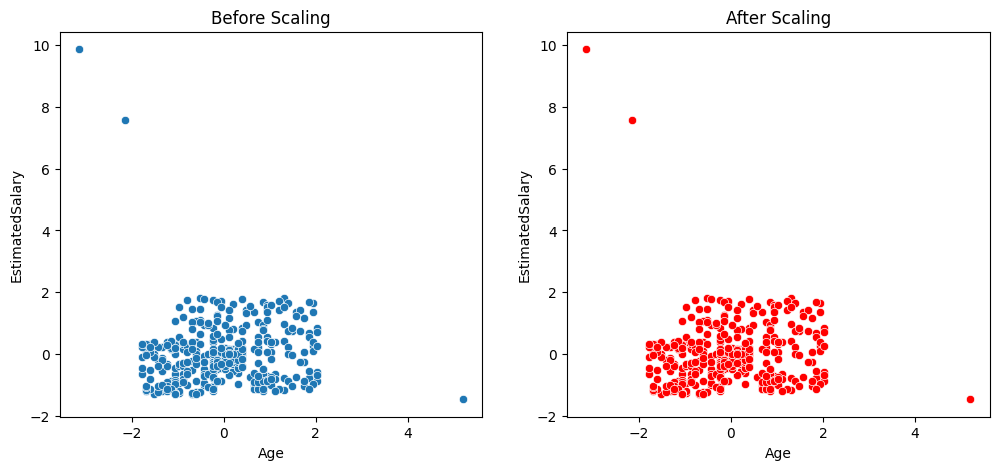

In [86]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(
    x=new_scaled['Age'], y=new_scaled['EstimatedSalary'], ax=axes[0]
)
sns.scatterplot(
    x=new_scaled['Age'], y=new_scaled['EstimatedSalary'], ax=axes[1], color='red'
)
axes[0].set_title('Before Scaling')
axes[1].set_title('After Scaling')

plt.show()